# Probability of OR

This notebook covers how to calculate the probability of *either* event $E$ **or** event $F$ happening.

- **Mutually Exclusive Events** — Events that cannot both happen
- **OR with Mutually Exclusive Events** — $P(E \cup F) = P(E) + P(F)$
- **OR with Non-Mutually Exclusive Events** — Inclusion-Exclusion principle
- **Inclusion-Exclusion for 3 Events** — Adding back the triple overlap
- **General Inclusion-Exclusion** — The $n$-event formula

**Credits:**
- Stanford CS109: Probability for Computer Scientists
  - [Probability of OR](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/prob_or/)

## Setup

In [41]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
from itertools import combinations

from libs.venn import venn, Color

np.random.seed(42)

print("Setup complete!")

Setup complete!


---

## 1. Mutually Exclusive Events

Two events $E$ and $F$ are **mutually exclusive** (also called *disjoint*) if they share no outcomes:

$$E \cap F = \emptyset$$

In plain English: **the two events can't both happen.**

| Example experiment | $E$ | $F$ | Mutually exclusive? |
|---|---|---|---|
| Roll a die | Even (2,4,6) | Odd (1,3,5) | Yes — no number is both |
| Draw a card | Spade | Heart | Yes — a card can't be both |
| Roll a die | Even (2,4,6) | ≤ 3 (1,2,3) | **No** — outcome 2 is in both |

In [42]:
# --- Demonstrate mutually exclusive vs. not ---

S_die = {1, 2, 3, 4, 5, 6}

E_even = {2, 4, 6}         # even numbers
F_odd  = {1, 3, 5}         # odd numbers
G_leq3 = {1, 2, 3}         # three or less

print("S (sample space):", S_die)
print()
print(f"E (even)      = {E_even}")
print(f"F (odd)       = {F_odd}")
print(f"E ∩ F         = {E_even & F_odd}  ← empty → mutually exclusive ✓")
print()
print(f"E (even)      = {E_even}")
print(f"G (≤ 3)       = {G_leq3}")
print(f"E ∩ G         = {E_even & G_leq3}  ← NOT empty → NOT mutually exclusive ✗")

S (sample space): {1, 2, 3, 4, 5, 6}

E (even)      = {2, 4, 6}
F (odd)       = {1, 3, 5}
E ∩ F         = set()  ← empty → mutually exclusive ✓

E (even)      = {2, 4, 6}
G (≤ 3)       = {1, 2, 3}
E ∩ G         = {2}  ← NOT empty → NOT mutually exclusive ✗


### Visualizing Mutually Exclusive Events

When two events are mutually exclusive, their regions in the sample space **do not overlap**.

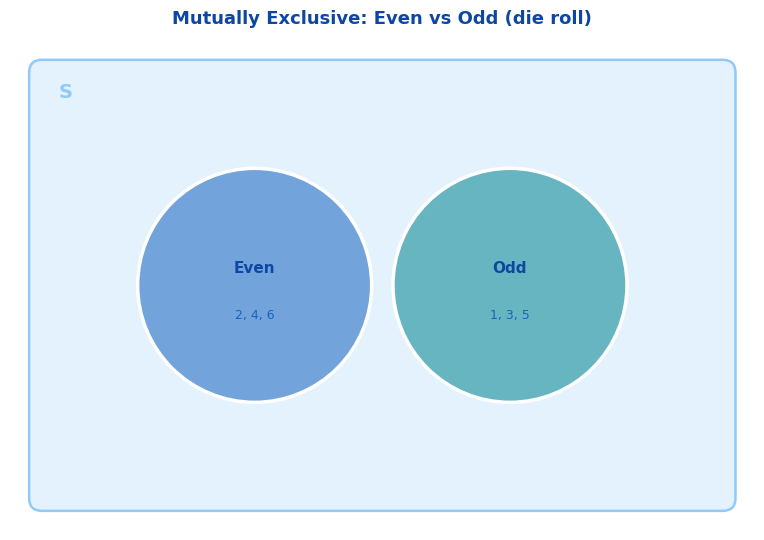

In [43]:
venn("""
venn-beta
    title "Mutually Exclusive: Even vs Odd (die roll)"
    set E["Even"]
        text e1["2, 4, 6"]
    set F["Odd"]
        text f1["1, 3, 5"]
""", color_scheme=Color.OCEAN)

Notice: **no overlap region** — the circles are separate. There is no outcome that belongs to both sets.

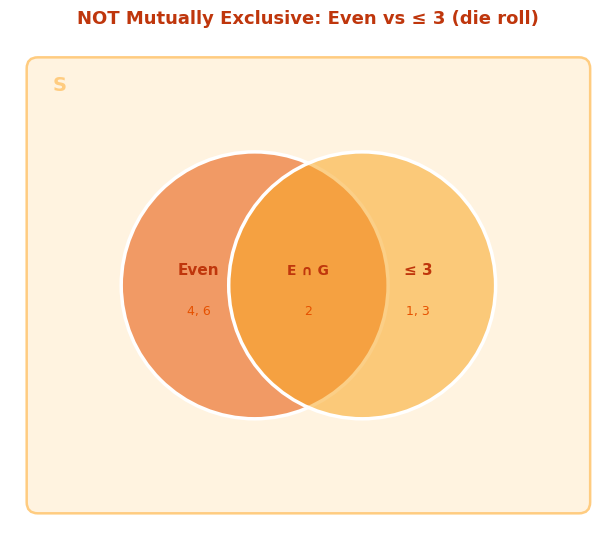

In [44]:
venn("""
venn-beta
    title "NOT Mutually Exclusive: Even vs ≤ 3 (die roll)"
    set E["Even"]
        text e1["4, 6"]
    set G["≤ 3"]
        text g1["1, 3"]
    union E, G["E ∩ G"]
        text eg1["2"]
""", color_scheme=Color.SUNSET)

The overlap region contains outcome **2** — it is both even *and* ≤ 3.

---

## 2. OR with Mutually Exclusive Events

> **Definition:** If $E$ and $F$ are **mutually exclusive**, then:
>
> $$P(E \cup F) = P(E) + P(F)$$

Since the events share no outcomes, there is nothing to double-count. We simply **add** the probabilities.

This extends to $n$ mutually exclusive events:

$$P(E_1 \cup E_2 \cup \cdots \cup E_n) = \sum_{i=1}^{n} P(E_i)$$

> **Note:** This is one of Kolmogorov's axioms of probability — we accept it *without proof*.

In [45]:
# --- Example: P(Even OR Odd) on a die ---

P_even = len(E_even) / len(S_die)
P_odd  = len(F_odd)  / len(S_die)

P_even_or_odd = P_even + P_odd   # mutually exclusive → just add

print(f"P(Even)          = {len(E_even)}/{len(S_die)} = {P_even:.4f}")
print(f"P(Odd)           = {len(F_odd)}/{len(S_die)} = {P_odd:.4f}")
print(f"P(Even ∪ Odd)    = {P_even:.4f} + {P_odd:.4f} = {P_even_or_odd:.4f}")
print()
print("Makes sense: every outcome is either even or odd, so P = 1.")

P(Even)          = 3/6 = 0.5000
P(Odd)           = 3/6 = 0.5000
P(Even ∪ Odd)    = 0.5000 + 0.5000 = 1.0000

Makes sense: every outcome is either even or odd, so P = 1.


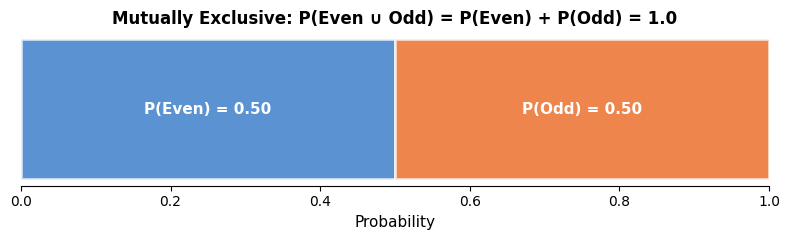

In [46]:
# --- Visual: stacking probabilities for mutually exclusive events ---

fig, ax = plt.subplots(figsize=(8, 2.5))

colors = ["#1565C0", "#E65100"]
labels = [f"P(Even) = {P_even:.2f}", f"P(Odd) = {P_odd:.2f}"]
lefts  = [0, P_even]
widths = [P_even, P_odd]

for i in range(2):
    ax.barh(0, widths[i], left=lefts[i], color=colors[i], alpha=0.7,
            edgecolor="white", linewidth=2, height=0.5)
    ax.text(lefts[i] + widths[i] / 2, 0, labels[i],
            ha="center", va="center", fontsize=11, fontweight="bold", color="white")

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Probability", fontsize=11)
ax.set_title("Mutually Exclusive: P(Even ∪ Odd) = P(Even) + P(Odd) = 1.0",
             fontsize=12, fontweight="semibold")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

### Example: Multiple Mutually Exclusive Events

What is $P(\text{roll 1 OR roll 3 OR roll 5})$ on a fair die?

These are mutually exclusive (a die shows exactly one face), so we just add:

In [47]:
# Each face is mutually exclusive
events = {"Roll 1": {1}, "Roll 3": {3}, "Roll 5": {5}}

total = 0
for name, event in events.items():
    p = len(event) / len(S_die)
    print(f"P({name}) = {p:.4f}")
    total += p

print(f"\nP(1 ∪ 3 ∪ 5) = {total:.4f}")
print(f"Verify:         {len({1,3,5})}/{len(S_die)} = {len({1,3,5})/len(S_die):.4f} ✓")

P(Roll 1) = 0.1667
P(Roll 3) = 0.1667
P(Roll 5) = 0.1667

P(1 ∪ 3 ∪ 5) = 0.5000
Verify:         3/6 = 0.5000 ✓


> ⚠️ **Caution:** Mutual exclusion only simplifies $P(E\ \text{or}\ F)$. It does **not** help with $P(E\ \text{and}\ F)$ — for mutually exclusive events, $P(E \cap F) = 0$ by definition.

---

## 3. OR with Non-Mutually Exclusive Events

What if the events **are not** mutually exclusive? Simply adding $P(E) + P(F)$ **double-counts** any outcome that belongs to *both* events.

### The Bug: Double-Counting

Consider a die roll. Let:
- $E$ = even numbers = $\{2, 4, 6\}$, so $P(E) = 0.5$
- $F$ = numbers $\leq 3$ = $\{1, 2, 3\}$, so $P(F) = 0.5$

If we naively add:

$$P(E \cup F) \stackrel{?}{=} P(E) + P(F) = 0.5 + 0.5 = 1.0$$

But outcome **5** is neither even nor $\leq 3$, so the probability **can't** be 1!

We **double-counted** outcome 2, which is in *both* $E$ and $F$.

In [48]:
# --- Show the double-counting bug ---

E = {2, 4, 6}   # even
F = {1, 2, 3}   # ≤ 3

P_E = len(E) / len(S_die)
P_F = len(F) / len(S_die)
P_E_and_F = len(E & F) / len(S_die)

buggy   = P_E + P_F
correct = len(E | F) / len(S_die)

print(f"E (even)  = {E}")
print(f"F (≤ 3)   = {F}")
print(f"E ∩ F     = {E & F}  ← this gets counted TWICE")
print(f"E ∪ F     = {E | F}")
print()
print(f"Buggy:   P(E) + P(F)           = {P_E} + {P_F} = {buggy}  ✗ (too high!)")
print(f"Correct: |E ∪ F| / |S|         = {len(E | F)}/{len(S_die)} = {correct:.4f} ✓")

E (even)  = {2, 4, 6}
F (≤ 3)   = {1, 2, 3}
E ∩ F     = {2}  ← this gets counted TWICE
E ∪ F     = {1, 2, 3, 4, 6}

Buggy:   P(E) + P(F)           = 0.5 + 0.5 = 1.0  ✗ (too high!)
Correct: |E ∪ F| / |S|         = 5/6 = 0.8333 ✓


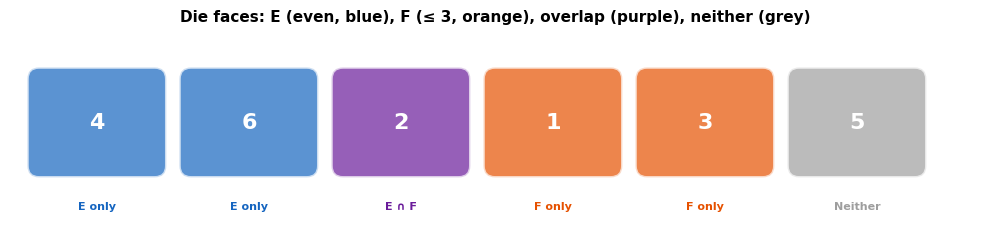

In [49]:
# --- Visual: show which die faces belong where ---

fig, ax = plt.subplots(figsize=(10, 3))

categories = {
    "E only":     {4, 6},
    "E ∩ F":      {2},
    "F only":     {1, 3},
    "Neither":    {5},
}
cat_colors = ["#1565C0", "#6A1B9A", "#E65100", "#9E9E9E"]

x = 0
for (cat, outcomes), color in zip(categories.items(), cat_colors):
    for val in sorted(outcomes):
        rect = patches.FancyBboxPatch((x, 0.2), 0.8, 0.6,
            boxstyle="round,pad=0.08", facecolor=color, alpha=0.7,
            edgecolor="white", linewidth=2)
        ax.add_patch(rect)
        ax.text(x + 0.4, 0.5, str(val), ha="center", va="center",
                fontsize=16, fontweight="bold", color="white")
        ax.text(x + 0.4, -0.05, cat, ha="center", va="top",
                fontsize=8, color=color, fontweight="bold")
        x += 1.05

ax.set_xlim(-0.2, x + 0.2)
ax.set_ylim(-0.25, 1.1)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Die faces: E (even, blue), F (≤ 3, orange), overlap (purple), neither (grey)",
             fontsize=11, fontweight="semibold", pad=10)
plt.tight_layout()
plt.show()

---

## 4. Inclusion-Exclusion Principle (Two Events)

> **Definition:** For **any** two events $E$ and $F$:
>
> $$\boxed{P(E \cup F) = P(E) + P(F) - P(E \cap F)}$$

We **include** $P(E)$ and $P(F)$, then **exclude** the double-counted intersection $P(E \cap F)$.

This works for **all** pairs of events:
- If $E, F$ are mutually exclusive → $P(E \cap F) = 0$, so the formula reduces to $P(E) + P(F)$ ✓
- If $E, F$ overlap → we subtract out the portion we counted twice

In [50]:
# --- Apply Inclusion-Exclusion to E = even, F = ≤ 3 ---

P_E = len(E) / len(S_die)
P_F = len(F) / len(S_die)
P_EF = len(E & F) / len(S_die)

P_E_or_F = P_E + P_F - P_EF

print("Inclusion-Exclusion:")
print(f"  P(E)       = {len(E)}/{len(S_die)} = {P_E:.4f}")
print(f"  P(F)       = {len(F)}/{len(S_die)} = {P_F:.4f}")
print(f"  P(E ∩ F)   = {len(E & F)}/{len(S_die)} = {P_EF:.4f}")
print()
print(f"  P(E ∪ F)   = {P_E:.4f} + {P_F:.4f} - {P_EF:.4f} = {P_E_or_F:.4f}")
print()

# Verify with the actual union
P_verify = len(E | F) / len(S_die)
print(f"  Verify:      |E ∪ F| / |S| = {len(E | F)}/{len(S_die)} = {P_verify:.4f} ✓")

Inclusion-Exclusion:
  P(E)       = 3/6 = 0.5000
  P(F)       = 3/6 = 0.5000
  P(E ∩ F)   = 1/6 = 0.1667

  P(E ∪ F)   = 0.5000 + 0.5000 - 0.1667 = 0.8333

  Verify:      |E ∪ F| / |S| = 5/6 = 0.8333 ✓


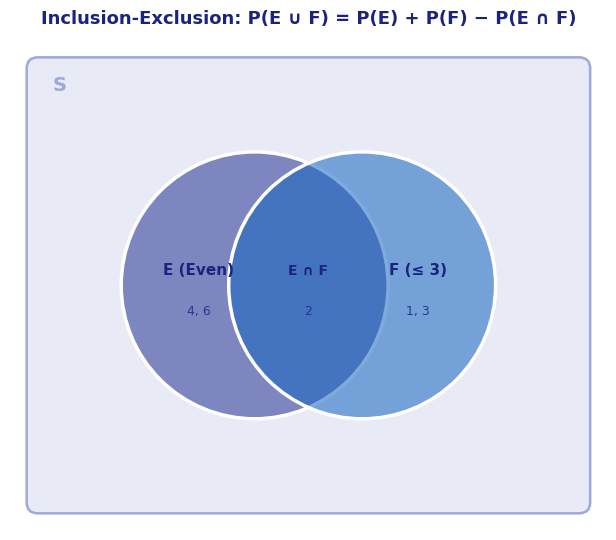

In [51]:
venn("""
venn-beta
    title "Inclusion-Exclusion: P(E ∪ F) = P(E) + P(F) − P(E ∩ F)"
    set E["E (Even)"]
        text e1["4, 6"]
    set F["F (≤ 3)"]
        text f1["1, 3"]
    union E, F["E ∩ F"]
        text ef1["2"]
""", color_scheme=Color.INDIGO)

### Visual Intuition

The stacked bar below shows the three pieces of the formula. The purple overlap is **subtracted** to avoid counting it twice.

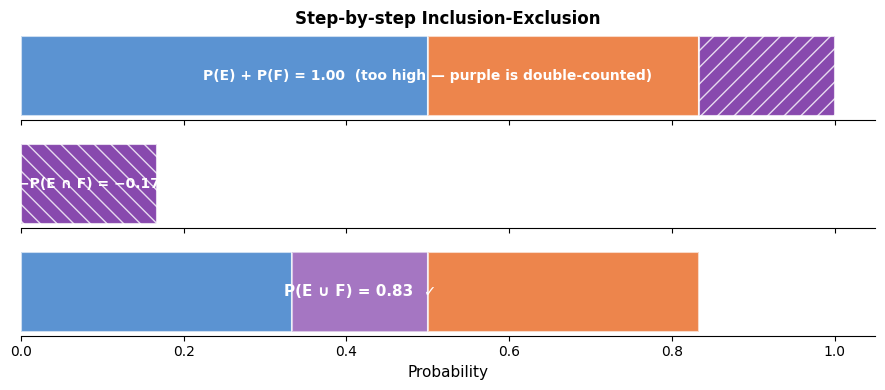

In [52]:
# --- Stacked bar: Inclusion-Exclusion visual ---

fig, axes = plt.subplots(3, 1, figsize=(9, 4), sharex=True)

blue   = "#1565C0"  # E
orange = "#E65100"  # F
purple = "#6A1B9A"  # E ∩ F

bar_h = 0.5

# Row 0: P(E) + P(F) — the naive sum with double-counted region
ax = axes[0]
ax.barh(0, P_E, color=blue, alpha=0.7, height=bar_h, edgecolor="white", linewidth=1.5)
ax.barh(0, P_F - P_EF, left=P_E, color=orange, alpha=0.7, height=bar_h, edgecolor="white", linewidth=1.5)
ax.barh(0, P_EF, left=P_E + P_F - P_EF, color=purple, alpha=0.8, height=bar_h,
        edgecolor="white", linewidth=1.5, hatch="//")
ax.text(0.5, 0, f"P(E) + P(F) = {P_E + P_F:.2f}  (too high — purple is double-counted)",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.set_yticks([])
ax.set_title("Step-by-step Inclusion-Exclusion", fontsize=12, fontweight="semibold")
ax.spines[["top", "right", "left"]].set_visible(False)

# Row 1: Subtract P(E ∩ F)
ax = axes[1]
ax.barh(0, P_EF, color=purple, alpha=0.8, height=bar_h, edgecolor="white", linewidth=1.5, hatch="\\\\")
ax.text(P_EF / 2, 0, f"−P(E ∩ F) = −{P_EF:.2f}", ha="center", va="center",
        fontsize=10, fontweight="bold", color="white")
ax.set_yticks([])
ax.spines[["top", "right", "left"]].set_visible(False)

# Row 2: Result
ax = axes[2]
ax.barh(0, P_E - P_EF, color=blue, alpha=0.7, height=bar_h, edgecolor="white", linewidth=1.5)
ax.barh(0, P_EF, left=P_E - P_EF, color=purple, alpha=0.6, height=bar_h, edgecolor="white", linewidth=1.5)
ax.barh(0, P_F - P_EF, left=P_E, color=orange, alpha=0.7, height=bar_h, edgecolor="white", linewidth=1.5)
ax.text((P_E + P_F - P_EF) / 2, 0, f"P(E ∪ F) = {P_E_or_F:.2f}  ✓",
        ha="center", va="center", fontsize=11, fontweight="bold", color="white")
ax.set_yticks([])
ax.set_xlabel("Probability", fontsize=11)
ax.set_xlim(0, 1.05)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

---

## 5. Inclusion-Exclusion: Three Events

For three events $E_1, E_2, E_3$:

$$P(E_1 \cup E_2 \cup E_3) = \underbrace{P(E_1) + P(E_2) + P(E_3)}_{\text{add singles}}$$
$$- \underbrace{P(E_1 \cap E_2) - P(E_1 \cap E_3) - P(E_2 \cap E_3)}_{\text{subtract pairs}}$$
$$+ \underbrace{P(E_1 \cap E_2 \cap E_3)}_{\text{add back triple}}$$

The pattern is:
1. **Add** probability of each individual event
2. **Subtract** probability of every pair co-occurring
3. **Add back** probability of all three co-occurring

In [53]:
# --- 3-event example: drawing a card ---
#
# Deck of cards:
#   52 cards, 4 suits × 13 ranks
#
#   E₁ = Hearts       (13 cards)
#   E₂ = Face cards   (12 cards: J, Q, K in each suit)
#   E₃ = Red cards    (26 cards: Hearts + Diamonds)

S_size = 52

E1 = set()  # Hearts
E2 = set()  # Face cards (J=11, Q=12, K=13)
E3 = set()  # Red cards (Hearts + Diamonds)

suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
ranks = list(range(1, 14))  # 1=Ace .. 13=King

for s in suits:
    for r in ranks:
        card = (s, r)
        if s == "Hearts":
            E1.add(card)
        if r >= 11:  # J, Q, K
            E2.add(card)
        if s in ("Hearts", "Diamonds"):
            E3.add(card)

P1  = len(E1) / S_size
P2  = len(E2) / S_size
P3  = len(E3) / S_size
P12 = len(E1 & E2) / S_size
P13 = len(E1 & E3) / S_size
P23 = len(E2 & E3) / S_size
P123 = len(E1 & E2 & E3) / S_size

P_union = P1 + P2 + P3 - P12 - P13 - P23 + P123
P_verify = len(E1 | E2 | E3) / S_size

print("Events from a standard 52-card deck:")
print(f"  E₁ (Hearts)     : {len(E1)} cards   P = {P1:.4f}")
print(f"  E₂ (Face cards) : {len(E2)} cards   P = {P2:.4f}")
print(f"  E₃ (Red cards)  : {len(E3)} cards   P = {P3:.4f}")
print()
print("Pairwise intersections:")
print(f"  E₁ ∩ E₂ (Hearts that are face cards)   : {len(E1 & E2)}  P = {P12:.4f}")
print(f"  E₁ ∩ E₃ (Hearts that are red)           : {len(E1 & E3)}  P = {P13:.4f}")
print(f"  E₂ ∩ E₃ (Face cards that are red)       : {len(E2 & E3)}  P = {P23:.4f}")
print()
print(f"  E₁ ∩ E₂ ∩ E₃ (Hearts, face, red)       : {len(E1 & E2 & E3)}  P = {P123:.4f}")
print()
print("Inclusion-Exclusion:")
print(f"  P(E₁∪E₂∪E₃) = {P1:.4f} + {P2:.4f} + {P3:.4f}")
print(f"               - {P12:.4f} - {P13:.4f} - {P23:.4f}")
print(f"               + {P123:.4f}")
print(f"               = {P_union:.4f}")
print(f"  Verify       = {len(E1 | E2 | E3)}/{S_size} = {P_verify:.4f} ✓")

Events from a standard 52-card deck:
  E₁ (Hearts)     : 13 cards   P = 0.2500
  E₂ (Face cards) : 12 cards   P = 0.2308
  E₃ (Red cards)  : 26 cards   P = 0.5000

Pairwise intersections:
  E₁ ∩ E₂ (Hearts that are face cards)   : 3  P = 0.0577
  E₁ ∩ E₃ (Hearts that are red)           : 13  P = 0.2500
  E₂ ∩ E₃ (Face cards that are red)       : 6  P = 0.1154

  E₁ ∩ E₂ ∩ E₃ (Hearts, face, red)       : 3  P = 0.0577

Inclusion-Exclusion:
  P(E₁∪E₂∪E₃) = 0.2500 + 0.2308 + 0.5000
               - 0.0577 - 0.2500 - 0.1154
               + 0.0577
               = 0.6154
  Verify       = 32/52 = 0.6154 ✓


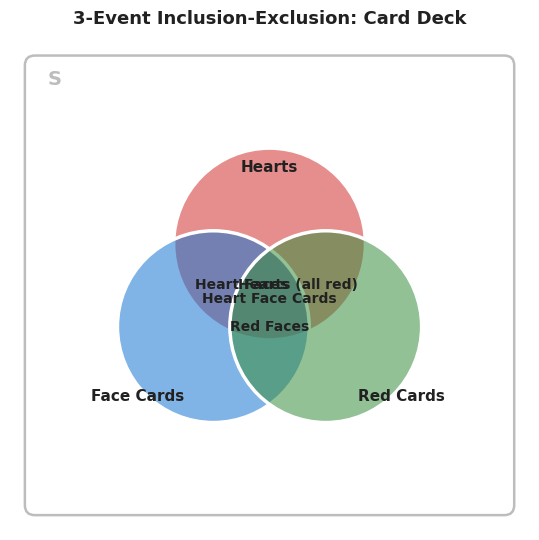

In [54]:
venn("""
venn-beta
    title "3-Event Inclusion-Exclusion: Card Deck"
    set E1["Hearts"]
    set E2["Face Cards"]
    set E3["Red Cards"]
    union E1, E2["Heart Faces"]
    union E1, E3["Hearts (all red)"]
    union E2, E3["Red Faces"]
    union E1, E2, E3["Heart Face Cards"]
""", color_scheme=Color.VIBRANT)

### Why We "Add Back" the Triple

The pattern of alternating addition/subtraction corrects for over- and under-counting:

| Step | What we do | Effect on regions |
|---|---|---|
| Add singles | $+P(E_1) + P(E_2) + P(E_3)$ | Pair overlaps counted **2×**, triple counted **3×** |
| Subtract pairs | $-P(E_1 \cap E_2) - P(E_1 \cap E_3) - P(E_2 \cap E_3)$ | Pair overlaps now **1×**, triple now **0×** |
| Add triple | $+P(E_1 \cap E_2 \cap E_3)$ | Triple now **1×** ✓ |

In [55]:
# --- Visual: step-by-step counting for 3 events ---
#
# Use a smaller sample space where we can count individual outcomes

S12 = set(range(1, 13))   # {1, 2, ..., 12}
A = {1, 2, 3, 4, 5}       # 5 elements
B = {3, 4, 5, 6, 7, 8}    # 6 elements
C = {5, 6, 7, 9, 10}      # 5 elements

# Count how many times each outcome is counted at each step
regions = {
    "A only":          A - B - C,
    "B only":          B - A - C,
    "C only":          C - A - B,
    "A∩B only":        (A & B) - C,
    "A∩C only":        (A & C) - B,
    "B∩C only":        (B & C) - A,
    "A∩B∩C":           A & B & C,
    "None":            S12 - A - B - C,
}

print(f"S = {{1..12}},  A = {sorted(A)},  B = {sorted(B)},  C = {sorted(C)}")
print()

header = f"{'Region':<12} {'Outcomes':<16} {'+ singles':>10} {'− pairs':>10} {'+ triple':>10} {'Final':>6}"
print(header)
print("─" * len(header))

for label, outcomes in regions.items():
    if not outcomes:
        continue
    # How many times counted by singles
    in_A = 1 if outcomes <= A or (outcomes & A) else 0
    in_B = 1 if outcomes <= B or (outcomes & B) else 0
    in_C = 1 if outcomes <= C or (outcomes & C) else 0
    # Simpler: check a representative element
    rep = next(iter(outcomes))
    s1 = (rep in A) + (rep in B) + (rep in C)
    s2 = (rep in A and rep in B) + (rep in A and rep in C) + (rep in B and rep in C)
    s3 = 1 if (rep in A and rep in B and rep in C) else 0
    final = s1 - s2 + s3
    print(f"{label:<12} {str(sorted(outcomes)):<16} {'+' + str(s1):>10} {'−' + str(s2):>10} {'+' + str(s3):>10} {final:>6}")

print()
P_inc_exc = len(A)/12 + len(B)/12 + len(C)/12 - len(A&B)/12 - len(A&C)/12 - len(B&C)/12 + len(A&B&C)/12
print(f"P(A∪B∪C) via inclusion-exclusion = {P_inc_exc:.4f}")
print(f"P(A∪B∪C) via direct count        = {len(A|B|C)}/12 = {len(A|B|C)/12:.4f} ✓")

S = {1..12},  A = [1, 2, 3, 4, 5],  B = [3, 4, 5, 6, 7, 8],  C = [5, 6, 7, 9, 10]

Region       Outcomes          + singles    − pairs   + triple  Final
─────────────────────────────────────────────────────────────────────
A only       [1, 2]                   +1         −0         +0      1
B only       [8]                      +1         −0         +0      1
C only       [9, 10]                  +1         −0         +0      1
A∩B only     [3, 4]                   +2         −1         +0      1
B∩C only     [6, 7]                   +2         −1         +0      1
A∩B∩C        [5]                      +3         −3         +1      1
None         [11, 12]                 +0         −0         +0      0

P(A∪B∪C) via inclusion-exclusion = 0.8333
P(A∪B∪C) via direct count        = 10/12 = 0.8333 ✓


---

## 6. General Inclusion-Exclusion ($n$ Events)

For $n$ events $E_1, E_2, \ldots, E_n$:

$$P\left(\bigcup_{i=1}^{n} E_i\right) = \sum_{r=1}^{n} (-1)^{r+1} Y_r$$

where

$$Y_r = \sum_{1 \leq i_1 < \cdots < i_r \leq n} P(E_{i_1} \cap \cdots \cap E_{i_r})$$

In words:

| Subset size $r$ | Action | Example ($n=4$) |
|---|---|---|
| 1 (singles) | **Add** all $P(E_i)$ | $+P(E_1) + P(E_2) + P(E_3) + P(E_4)$ |
| 2 (pairs) | **Subtract** all $P(E_i \cap E_j)$ | $-P(E_1 \cap E_2) - P(E_1 \cap E_3) - \cdots$ |
| 3 (triples) | **Add** all $P(E_i \cap E_j \cap E_k)$ | $+P(E_1 \cap E_2 \cap E_3) + \cdots$ |
| 4 (quadruple) | **Subtract** $P(E_1 \cap E_2 \cap E_3 \cap E_4)$ | $-P(E_1 \cap E_2 \cap E_3 \cap E_4)$ |

The sign **alternates**: add for odd $r$, subtract for even $r$.

In [56]:
def inclusion_exclusion(events, S_size, verbose=True):
    """Compute P(E₁ ∪ E₂ ∪ ... ∪ Eₙ) using the general inclusion-exclusion formula."""
    n = len(events)
    total = 0.0

    for r in range(1, n + 1):
        sign = (-1) ** (r + 1)
        sign_str = "+" if sign > 0 else "−"
        Y_r = 0.0

        for combo in combinations(range(n), r):
            # Intersection of all events in this combo
            intersection = events[combo[0]]
            for idx in combo[1:]:
                intersection = intersection & events[idx]
            p = len(intersection) / S_size
            Y_r += p

            if verbose:
                names = " ∩ ".join(f"E{i+1}" for i in combo)
                print(f"    {sign_str} P({names}) = {len(intersection)}/{S_size} = {p:.4f}")

        total += sign * Y_r
        if verbose:
            print(f"  After size-{r} terms (Y_{r} = {Y_r:.4f}): running total = {total:.4f}")
            print()

    return total

In [57]:
# --- 4-event example ---
#
# Roll a 20-sided die.  S = {1, 2, ..., 20}
#
# E₁ = divisible by 2   → {2,4,6,8,10,12,14,16,18,20}
# E₂ = divisible by 3   → {3,6,9,12,15,18}
# E₃ = divisible by 5   → {5,10,15,20}
# E₄ = prime numbers    → {2,3,5,7,11,13,17,19}

S20 = set(range(1, 21))
events = [
    {x for x in S20 if x % 2 == 0},      # E₁: even
    {x for x in S20 if x % 3 == 0},      # E₂: divisible by 3
    {x for x in S20 if x % 5 == 0},      # E₃: divisible by 5
    {2, 3, 5, 7, 11, 13, 17, 19},        # E₄: primes
]

for i, ev in enumerate(events):
    print(f"E{i+1} = {sorted(ev)}  (|E{i+1}| = {len(ev)})")
print()

print("=" * 60)
print("Inclusion-Exclusion computation:")
print("=" * 60)
p_ie = inclusion_exclusion(events, len(S20))

# Verify
actual_union = events[0] | events[1] | events[2] | events[3]
p_verify = len(actual_union) / len(S20)

print(f"Inclusion-Exclusion result:  P = {p_ie:.4f}")
print(f"Direct count:               |union| / |S| = {len(actual_union)}/{len(S20)} = {p_verify:.4f} ✓")
print(f"Outcomes NOT in any event:   {sorted(S20 - actual_union)}")

E1 = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]  (|E1| = 10)
E2 = [3, 6, 9, 12, 15, 18]  (|E2| = 6)
E3 = [5, 10, 15, 20]  (|E3| = 4)
E4 = [2, 3, 5, 7, 11, 13, 17, 19]  (|E4| = 8)

Inclusion-Exclusion computation:
    + P(E1) = 10/20 = 0.5000
    + P(E2) = 6/20 = 0.3000
    + P(E3) = 4/20 = 0.2000
    + P(E4) = 8/20 = 0.4000
  After size-1 terms (Y_1 = 1.4000): running total = 1.4000

    − P(E1 ∩ E2) = 3/20 = 0.1500
    − P(E1 ∩ E3) = 2/20 = 0.1000
    − P(E1 ∩ E4) = 1/20 = 0.0500
    − P(E2 ∩ E3) = 1/20 = 0.0500
    − P(E2 ∩ E4) = 1/20 = 0.0500
    − P(E3 ∩ E4) = 1/20 = 0.0500
  After size-2 terms (Y_2 = 0.4500): running total = 0.9500

    + P(E1 ∩ E2 ∩ E3) = 0/20 = 0.0000
    + P(E1 ∩ E2 ∩ E4) = 0/20 = 0.0000
    + P(E1 ∩ E3 ∩ E4) = 0/20 = 0.0000
    + P(E2 ∩ E3 ∩ E4) = 0/20 = 0.0000
  After size-3 terms (Y_3 = 0.0000): running total = 0.9500

    − P(E1 ∩ E2 ∩ E3 ∩ E4) = 0/20 = 0.0000
  After size-4 terms (Y_4 = 0.0000): running total = 0.9500

Inclusion-Exclusion result:  P = 0.9500
Dir

### Complexity of Inclusion-Exclusion

The general formula requires computing $2^n - 1$ terms (every non-empty subset of events). This grows **exponentially**!

| $n$ events | Number of terms |
|---|---|
| 2 | 3 |
| 3 | 7 |
| 4 | 15 |
| 5 | 31 |
| 10 | 1,023 |
| 20 | 1,048,575 |

> **Practical tip:** If possible, look for mutually exclusive decompositions or other methods before resorting to inclusion-exclusion with many events.

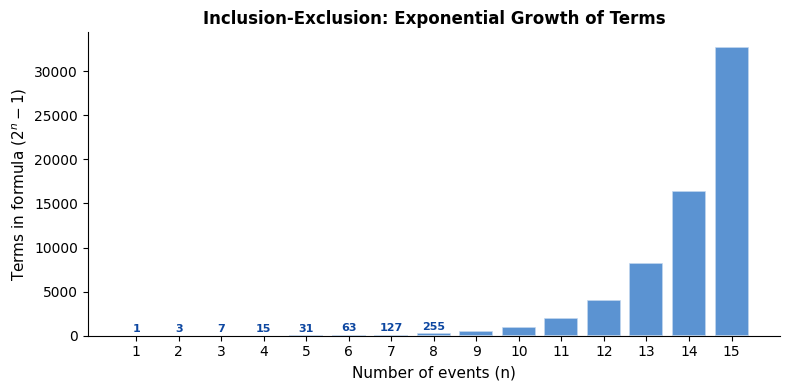

In [58]:
# --- Visual: exponential growth of terms ---

ns = np.arange(1, 16)
terms = 2**ns - 1

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(ns, terms, color="#1565C0", alpha=0.7, edgecolor="white", linewidth=1.2)

for bar, t in zip(bars, terms):
    if t < 500:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                str(t), ha="center", va="bottom", fontsize=8, fontweight="bold", color="#0D47A1")

ax.set_xlabel("Number of events (n)", fontsize=11)
ax.set_ylabel("Terms in formula ($2^n - 1$)", fontsize=11)
ax.set_title("Inclusion-Exclusion: Exponential Growth of Terms",
             fontsize=12, fontweight="semibold")
ax.set_xticks(ns)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---

## 7. Monte Carlo Verification

We can verify the inclusion-exclusion formula empirically by **simulating** random outcomes and checking how often at least one event occurs.

In [59]:
# --- Monte Carlo simulation: 4-event die example ---

N_TRIALS = 100_000
S_list = list(S20)

rolls = np.random.choice(S_list, size=N_TRIALS)

# Check if each roll is in at least one event
union_set = events[0] | events[1] | events[2] | events[3]
hits = np.array([r in union_set for r in rolls])
p_sim = hits.mean()

print(f"Monte Carlo estimate ({N_TRIALS:,} trials):  P(E₁∪E₂∪E₃∪E₄) ≈ {p_sim:.4f}")
print(f"Inclusion-Exclusion exact:             P(E₁∪E₂∪E₃∪E₄) = {p_ie:.4f}")
print(f"Difference:                            {abs(p_sim - p_ie):.4f}")

Monte Carlo estimate (100,000 trials):  P(E₁∪E₂∪E₃∪E₄) ≈ 0.9503
Inclusion-Exclusion exact:             P(E₁∪E₂∪E₃∪E₄) = 0.9500
Difference:                            0.0003


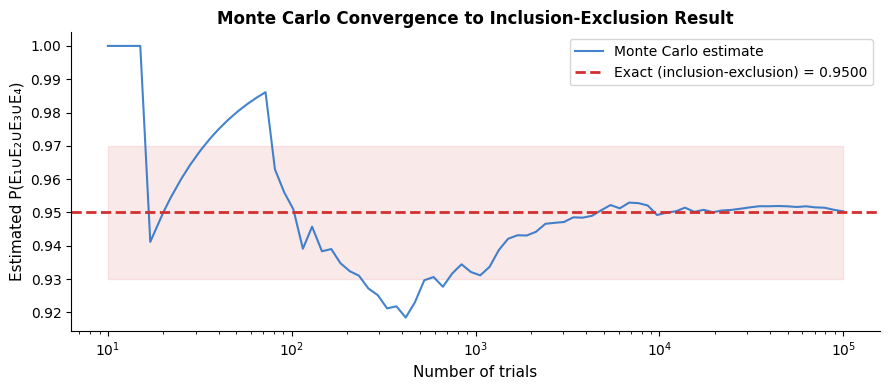

In [60]:
# --- Convergence plot: Monte Carlo estimate vs. exact ---

sample_sizes = np.logspace(1, 5, 80).astype(int)
estimates = []

for n in sample_sizes:
    subset = rolls[:n]
    est = np.mean([r in union_set for r in subset])
    estimates.append(est)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(sample_sizes, estimates, color="#1565C0", alpha=0.8, linewidth=1.5,
            label="Monte Carlo estimate")
ax.axhline(p_ie, color="#D32F2F", linestyle="--", linewidth=2,
           label=f"Exact (inclusion-exclusion) = {p_ie:.4f}")
ax.fill_between(sample_sizes, p_ie - 0.02, p_ie + 0.02, color="#D32F2F", alpha=0.1)
ax.set_xlabel("Number of trials", fontsize=11)
ax.set_ylabel("Estimated P(E₁∪E₂∪E₃∪E₄)", fontsize=11)
ax.set_title("Monte Carlo Convergence to Inclusion-Exclusion Result",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---

## 8. Summary

| Scenario | Formula |
|---|---|
| $E, F$ mutually exclusive | $P(E \cup F) = P(E) + P(F)$ |
| $E, F$ any events | $P(E \cup F) = P(E) + P(F) - P(E \cap F)$ |
| $n$ mutually exclusive events | $P(\bigcup E_i) = \sum P(E_i)$ |
| $n$ general events | $P(\bigcup E_i) = \sum_{r=1}^{n}(-1)^{r+1} \sum P(\text{intersections of } r \text{ events})$ |

### Key Takeaways

1. **Mutually exclusive** events make OR easy — just **add** probabilities
2. For non-mutually-exclusive events, naive addition **double-counts** overlapping outcomes
3. The **Inclusion-Exclusion** principle corrects for this by alternately adding and subtracting
4. The general formula has $2^n - 1$ terms — **exponential** in the number of events
5. When possible, prefer finding mutually exclusive decompositions over brute-force inclusion-exclusion